# **Title: AI-Powered Anomaly Detection for Fraudulent System Activities**



### **Step 1: Problem Understanding & Framing**

*   In enterprise systems, particularly in the insurance industry, large volumes of sensitive data such as policy records, claims, and financial transactions are processed daily. Because of this, these systems are highly exposed to cybersecurity risks like abnormal traffic behavior, unauthorized access, and suspicious system activities. Based on my experience working in IT, I’ve seen that traditional monitoring approaches are mostly rule-based and reactive, which makes it difficult to detect new or unknown threats early.

*   For this project, I built an AI-based anomaly detection pipeline to identify unusual patterns in network traffic data. Since the dataset does not contain reliable labels for normal versus malicious behavior, I framed the problem as an unsupervised learning task. I implemented and compared three different approaches: Isolation Forest (isolation-based), K-Means (distance-based), and DBSCAN (density-based) to evaluate how each model detects anomalies.

* Based on the comparison results, both Isolation Forest and K-Means detected 1,260 anomalies (5.0%), while DBSCAN detected 3,122 anomalies (12.39%), which is significantly higher. This indicates that DBSCAN is more aggressive in labeling anomalies, while Isolation Forest and K-Means provide more controlled and consistent detection. Between the models, Isolation Forest is more suitable as the primary approach because it is specifically designed for anomaly detection and provides more stable and interpretable results compared to clustering-based methods.

* One of the key challenges in this problem is that anomalies are not always equivalent to malicious activity, and different models may produce different results depending on how they define “unusual behavior.” To address this, I compared outputs across models, reviewed anomaly distributions, and analyzed feature patterns to ensure that the detected anomalies are meaningful and not just noise.

* Another important consideration is balancing detection sensitivity. Models like DBSCAN may detect more anomalies but can introduce more false positives, while models like Isolation Forest provide a better balance between detecting suspicious behavior and maintaining realistic system patterns. In this project, I selected Isolation Forest as the final model because it offers a more practical and reliable approach for real-world anomaly detection scenarios.







In [1]:
# ----------------------------
# Imports
# ----------------------------
# Core utilities, data handling, visualization, preprocessing,
# dimensionality reduction, clustering/anomaly models, and artifact export.
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib


### **Step 2: Data Collection & Understanding**

The dataset used in this project is a publicly available cybersecurity network traffic dataset loaded from Google Drive into Colab. It contains around 25k records with multiple features describing connection behavior, traffic volume, and login-related activity.

I started by inspecting the dataset using basic checks like .shape, .head(), .info(), and .describe() to understand the structure and data types. I also checked for missing values and duplicates to ensure data quality before preprocessing.

The dataset includes a mix of numeric and categorical features, such as:

* Traffic metrics (src_bytes, dst_bytes)
* Connection stats (count, srv_count)
* Login indicators (num_failed_logins, logged_in)
* Network attributes (protocol_type, service, flag)

This type of dataset is suitable for anomaly detection since it represents real system logs where abnormal behavior needs to be identified without predefined labels.

**Data Dictionary (Key Features)**

| Variable Name     | Type        | Description                     |
| ----------------- | ----------- | ------------------------------- |
| duration          | Numeric     | Length of connection/session    |
| protocol_type     | Categorical | Protocol used (TCP, UDP, ICMP)  |
| service           | Categorical | Network service accessed        |
| flag              | Categorical | Status of connection            |
| src_bytes         | Numeric     | Data sent from source           |
| dst_bytes         | Numeric     | Data received                   |
| num_failed_logins | Numeric     | Number of failed login attempts |
| logged_in         | Binary      | Login success indicator         |
| count             | Numeric     | Connections to same host        |
| srv_count         | Numeric     | Connections to same service     |


In [2]:
# ----------------------------
# Load Dataset
# ----------------------------
# Mount Google Drive so the notebook can read the source CSV in Colab.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Read the training dataset from Google Drive and print a quick sanity check.
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Train_data.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
len(df)


Dataset loaded successfully.
Shape: (25192, 42)

First 5 rows:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                    0.00                  

25192

In [4]:
# ----------------------------
# Data Understanding
# ----------------------------
# Basic dataset profiling before preprocessing:
# - schema / column names
# - dtypes
# - missing values
# - duplicate rows
# - record count
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTotal Count Rows:", len(df))



Column Names:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class']

Data Types:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64


### **Step 3: Data Preprocessing, EDA & Feature Engineering**



In this step, I prepared the dataset for modeling by cleaning and transforming the data. I handled missing values using median imputation for numeric columns and mode for categorical columns, then removed duplicate rows to avoid redundant data.

To control extreme values, I applied IQR-based capping on numeric features. This helps reduce noise while still preserving potential anomalies. For EDA, I used summary statistics, histograms, boxplots, and a correlation heatmap to understand feature distributions and relationships.

For feature engineering, I encoded categorical variables using LabelEncoder and created additional features that capture behavioral patterns:

* login_failure_ratio
* byte_ratio
* service_to_host_ratio
* dst_host_service_ratio

After that, I scaled the dataset using StandardScaler to normalize feature ranges. I also applied PCA for dimensionality reduction and visualization, and tested clustering using K-Means to check if the data forms natural groupings.

In [5]:
# ----------------------------
# Data Cleaning
# ----------------------------
# Split columns by dtype because numeric and categorical fields
# use different imputation strategies.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Impute missing values:
# - numeric: median (robust to skew/outliers)
# - categorical: mode (most frequent category)
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nTotal missing values after imputation:", df.isnull().sum().sum())

# Drop exact duplicate rows to avoid overweighting repeated observations.
before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]
print(f"Removed {before_rows - after_rows} duplicate rows.")

# Cap numeric outliers using the IQR rule instead of removing rows.
# This keeps the dataset size intact while reducing extreme distortion.
def cap_outliers_iqr(dataframe, columns):
    df_out = dataframe.copy()
    for col in columns:
        q1 = df_out[col].quantile(0.25)
        q3 = df_out[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df_out[col] = np.where(df_out[col] < lower, lower, df_out[col])
        df_out[col] = np.where(df_out[col] > upper, upper, df_out[col])
    return df_out

df = cap_outliers_iqr(df, numeric_cols)

print("\nShape after cleaning:", df.shape)



Total missing values after imputation: 0
Removed 0 duplicate rows.

Shape after cleaning: (25192, 42)



Summary Statistics:
       duration     src_bytes     dst_bytes     land  wrong_fragment   urgent  \
count   25192.0  25192.000000  25192.000000  25192.0         25192.0  25192.0   
mean        0.0    171.689644    350.957204      0.0             0.0      0.0   
std         0.0    225.629906    521.782683      0.0             0.0      0.0   
min         0.0      0.000000      0.000000      0.0             0.0      0.0   
25%         0.0      0.000000      0.000000      0.0             0.0      0.0   
50%         0.0     44.000000      0.000000      0.0             0.0      0.0   
75%         0.0    279.000000    530.250000      0.0             0.0      0.0   
max         0.0    697.500000   1325.625000      0.0             0.0      0.0   

           hot  num_failed_logins     logged_in  num_compromised  ...  \
count  25192.0            25192.0  25192.000000          25192.0  ...   
mean       0.0                0.0      0.394768              0.0  ...   
std        0.0                

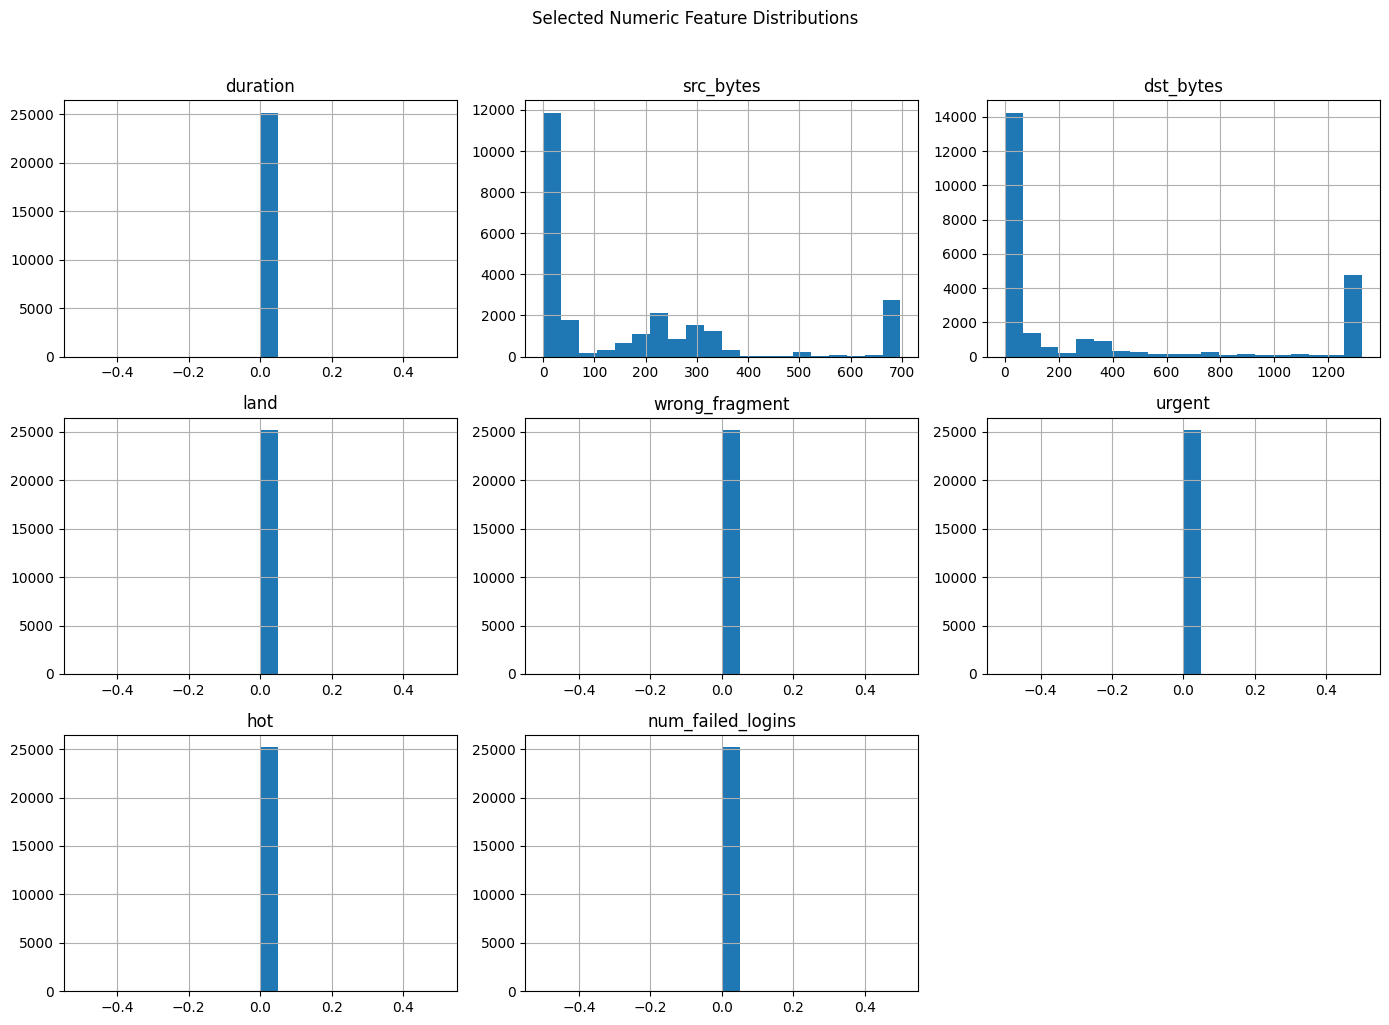

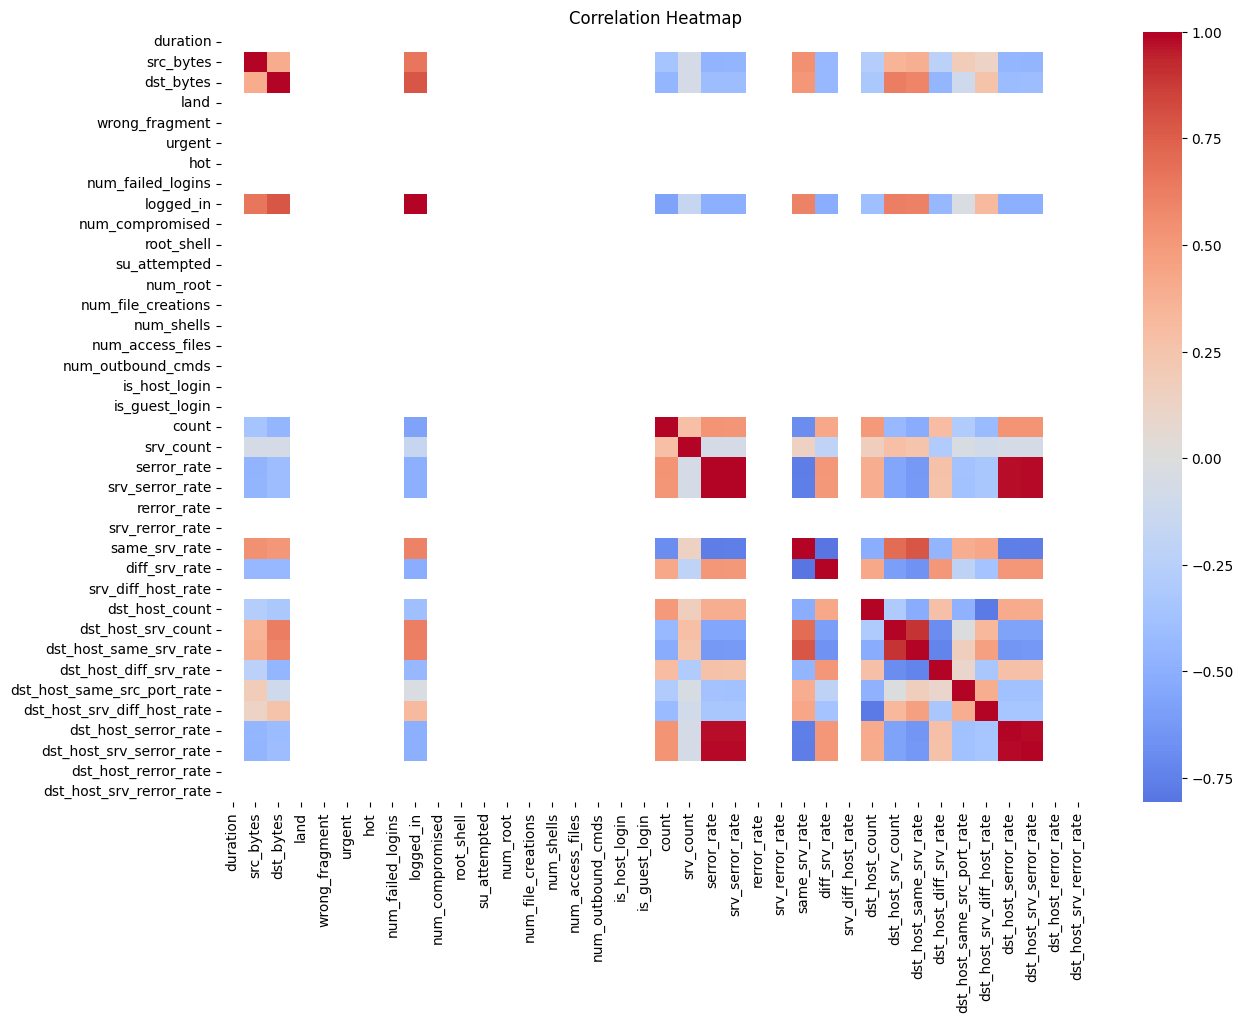

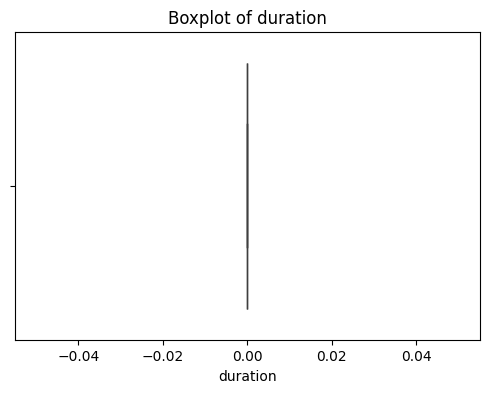

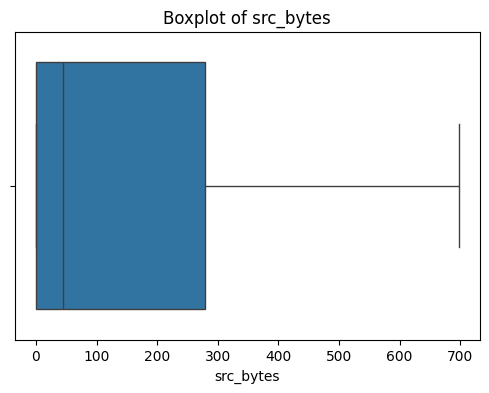

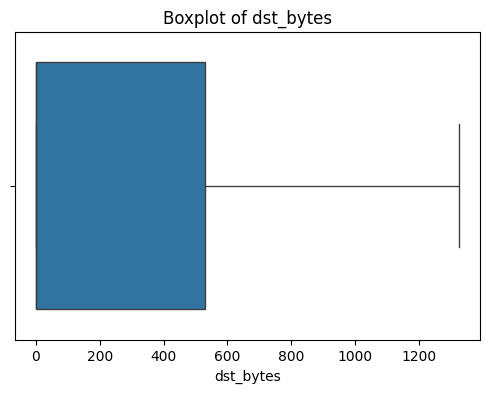

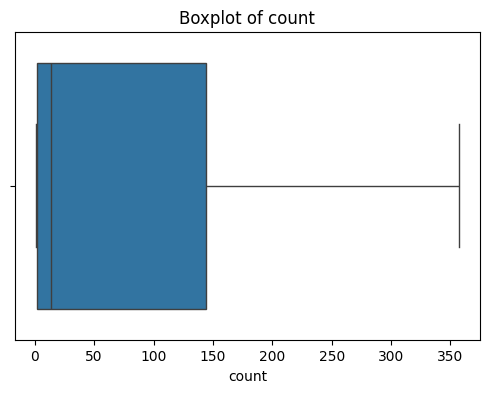

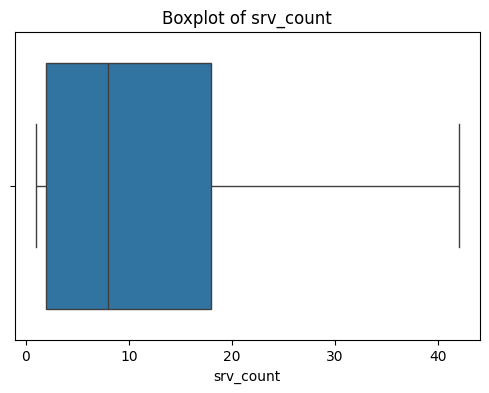

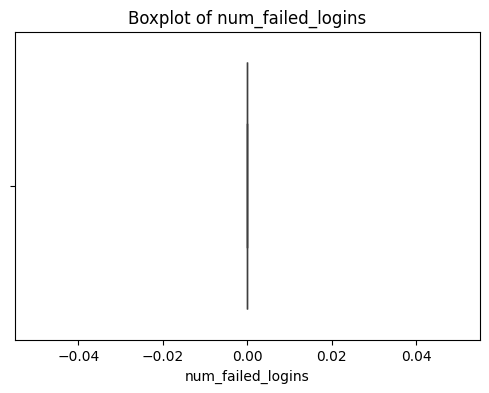

In [6]:
# ----------------------------
# Exploratory Data Analysis
# ----------------------------
# Summary stats for numeric features.
print("\nSummary Statistics:")
print(df.describe())

# Histogram view for a subset of numeric columns to inspect
# distribution shape, spread, and skew.
selected_numeric = numeric_cols[:8]
df[selected_numeric].hist(figsize=(14, 10), bins=20)
plt.suptitle("Selected Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features.
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Boxplots for key traffic-related features to inspect spread and extremes.
important_cols = ["duration", "src_bytes", "dst_bytes", "count", "srv_count", "num_failed_logins"]
important_cols = [col for col in important_cols if col in df.columns]

for col in important_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [7]:
# ----------------------------
# Feature Engineering
# ----------------------------
# Encode categorical columns so downstream models can consume them.
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Create ratio-based features to capture behavior patterns that
# are harder to see from raw counts alone.
if "num_failed_logins" in df.columns and "count" in df.columns:
    # Failed logins relative to overall connection count.
    df["login_failure_ratio"] = df["num_failed_logins"] / (df["count"] + 1)

if "src_bytes" in df.columns and "dst_bytes" in df.columns:
    # Outbound vs inbound traffic balance.
    df["byte_ratio"] = df["src_bytes"] / (df["dst_bytes"] + 1)

if "srv_count" in df.columns and "count" in df.columns:
    # Service-level activity relative to host-level activity.
    df["service_to_host_ratio"] = df["srv_count"] / (df["count"] + 1)

if "dst_host_srv_count" in df.columns and "dst_host_count" in df.columns:
    # Service concentration at the destination host.
    df["dst_host_service_ratio"] = df["dst_host_srv_count"] / (df["dst_host_count"] + 1)

print("\nShape after feature engineering:", df.shape)

# Standardize features so high-magnitude columns do not dominate distance-based methods.
X = df.copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print("\nScaled dataset shape:", X_scaled.shape)



Shape after feature engineering: (25192, 46)

Scaled dataset shape: (25192, 46)



Explained Variance Ratio:
[0.42027771 0.10498947]


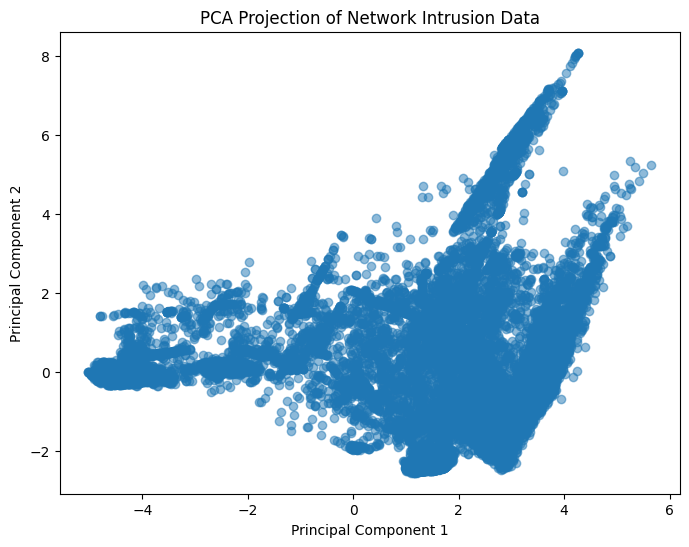

In [8]:
# ----------------------------
# Dimensionality Reduction
# ----------------------------
# Reduce the feature space to 2 principal components for visualization.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Scatter plot of the PCA projection.
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title("PCA Projection of Network Intrusion Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


### **Step 4: Model Implementation**

In this project, I implemented three different unsupervised models to detect anomalies: Isolation Forest (isolation-based), K-Means (distance-based), and DBSCAN (density-based). The goal was to compare how each approach identifies unusual patterns in the dataset.

**4.1. Isolation Forest**
    For Isolation Forest, I used n_estimators=200 and contamination=0.05. This model works by randomly splitting the data and isolating observations that are easier to separate, which are considered anomalies. Based on the results, Isolation Forest detected 1,260 anomalies (5.0%), which aligns directly with the contamination parameter and provides a controlled anomaly detection rate.

**4.2. K-Means Clustering**
    For K-Means, I applied clustering and calculated the distance of each data point from its assigned cluster centroid. Points that are far from the center were treated as anomalies. Interestingly, K-Means also detected 1,260 anomalies (5.0%), similar to Isolation Forest. However, since K-Means is not specifically designed for anomaly detection, its results depend heavily on cluster structure and may not always reflect true abnormal behavior.

**4.3. DBSCAN**
    For DBSCAN, I used a density-based approach where points that do not belong to any cluster are labeled as noise (anomalies). This model detected 3,122 anomalies (12.39%), which is significantly higher than the other models. This indicates that DBSCAN is more sensitive and tends to classify more points as anomalies, which may include both true anomalies and noise.

**Model Comparison Insight**
* Isolation Forest → 1,260 anomalies (5.0%)
* K-Means → 1,260 anomalies (5.0%)
* DBSCAN → 3,122 anomalies (12.39%)

Based on this comparison, Isolation Forest is the most appropriate model because:

* It is specifically designed for anomaly detection
* It provides a controlled and interpretable anomaly rate
* It produces consistent results without over-detecting anomalies
* It aligns better with real-world expectations compared to DBSCAN

Although K-Means produced similar results, it is not inherently an anomaly detection model, and DBSCAN, while useful, is more aggressive and may introduce more false positives.

#### **4.1 Isolation Forest**


Isolation Forest Results:
Anomalies detected: 1260


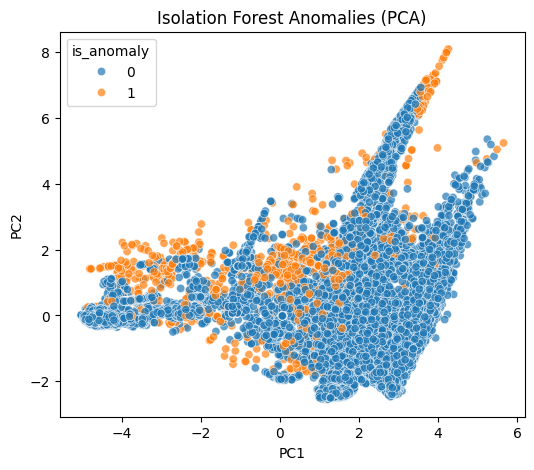

In [9]:
# ----------------------------
# Isolation Forest Model
# ----------------------------
# Main unsupervised anomaly detector.
start_time = time.time()

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Fit on the scaled feature matrix.
iso_model.fit(X_scaled)

training_time = round(time.time() - start_time, 2)

# Isolation Forest returns:
# -1 -> anomaly
#  1 -> normal
predictions = iso_model.predict(X_scaled)

# Normalize predictions to a binary flag used across the notebook.
df["is_anomaly"] = np.where(predictions == -1, 1, 0)

# Lower decision_function values indicate stronger anomaly candidates.
df["anomaly_score"] = iso_model.decision_function(X_scaled)

# ----------------------------
# Isolation Forest Summary
# ----------------------------
anomaly_count = df["is_anomaly"].sum()
total_count = len(df)
anomaly_pct = (anomaly_count / total_count) * 100

print("\nIsolation Forest Results:")
print("Anomalies detected:", anomaly_count)

# Assemble PCA coordinates with model outputs for plotting.
plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
plot_df["is_anomaly"] = df["is_anomaly"].values
plot_df["anomaly_score"] = df["anomaly_score"].values

# Plot anomaly flags in PCA space.
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="is_anomaly",
    alpha=0.7
)
plt.title("Isolation Forest Anomalies (PCA)")
plt.show()


#### **4.2 K-Means (Distance-Based Anomaly Detection)**


K-Means Results:

K-Means Silhouette Score: 0.3769
K-Means anomalies detected: 1260


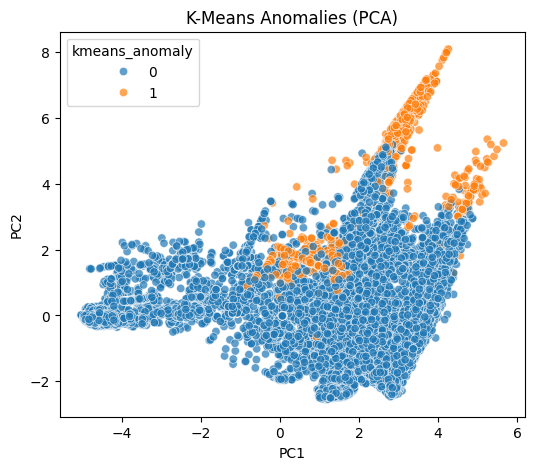

In [10]:
# ----------------------------
# K-Means Clustering + Anomaly Detection
# ----------------------------
# Comparison baseline: treat points far from their assigned centroid as anomalies.
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Distance to the nearest centroid is used as the anomaly score proxy.
distances = kmeans.transform(X_scaled)
min_distances = np.min(distances, axis=1)

# Persist cluster assignments and centroid distances.
df["kmeans_cluster"] = cluster_labels
df["kmeans_distance"] = min_distances

# Flag the top 5% most distant points as anomalies.
threshold = np.percentile(min_distances, 95)
df["kmeans_anomaly"] = np.where(min_distances >= threshold, 1, 0)

# Silhouette score gives a quick read on cluster separation.
print("\nK-Means Results:")
sil_score = silhouette_score(X_scaled, cluster_labels)
print("\nK-Means Silhouette Score:", round(sil_score, 4))

print("K-Means anomalies detected:", df["kmeans_anomaly"].sum())

# Plot K-Means anomaly flags in PCA space.
plot_df["kmeans_anomaly"] = df["kmeans_anomaly"].values

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="kmeans_anomaly",
    alpha=0.7
)
plt.title("K-Means Anomalies (PCA)")
plt.show()


#### **4.3 DBSCAN (Density-Based Anomaly Detection)**


DBScan Results:

DBSCAN anomalies detected: 3122


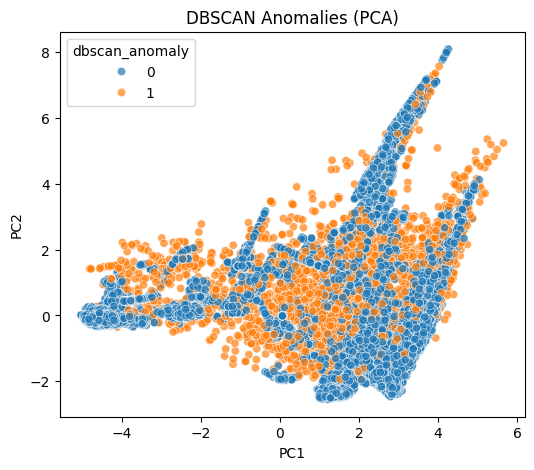

In [11]:
# ----------------------------
# DBSCAN Anomaly Detection
# ----------------------------
from sklearn.cluster import DBSCAN

# Density-based comparison model.
# Points labeled as noise (-1) are treated as anomalies.
dbscan = DBSCAN(eps=0.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Persist raw cluster labels.
df["dbscan_cluster"] = dbscan_labels

print("\nDBScan Results:")
df["dbscan_anomaly"] = np.where(dbscan_labels == -1, 1, 0)

print("\nDBSCAN anomalies detected:", df["dbscan_anomaly"].sum())

# Plot DBSCAN anomaly flags in PCA space.
plot_df["dbscan_anomaly"] = df["dbscan_anomaly"].values

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=plot_df,
    x="PC1", y="PC2",
    hue="dbscan_anomaly",
    alpha=0.7
)
plt.title("DBSCAN Anomalies (PCA)")
plt.show()


In [12]:
# ----------------------------
# Model Comparison
# ----------------------------
# Compare the number of records flagged by each method.
print("\n--- Model Comparison ---")

print("Isolation Forest anomalies:", df["is_anomaly"].sum())
print("K-Means anomalies:", df["kmeans_anomaly"].sum())
print("DBSCAN anomalies:", df["dbscan_anomaly"].sum())



--- Model Comparison ---
Isolation Forest anomalies: 1260
K-Means anomalies: 1260
DBSCAN anomalies: 3122



Isolation Forest vs K-Means
[[23255   677]
 [  677   583]]


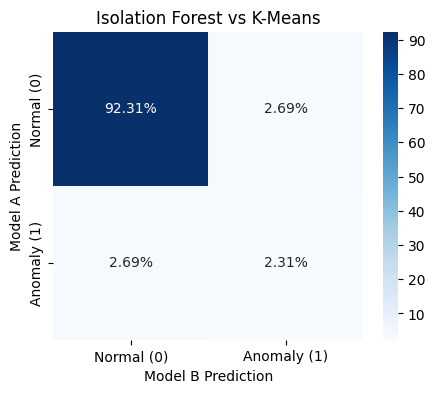


Isolation Forest vs DBSCAN
[[21461  2471]
 [  609   651]]


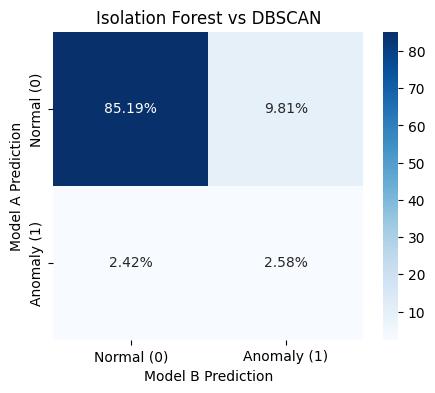


K-Means vs DBSCAN
[[21064  2868]
 [ 1006   254]]


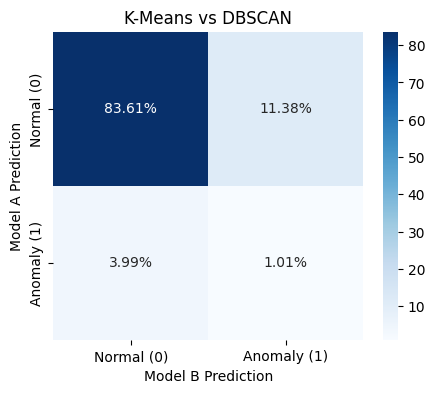

In [13]:
# ----------------------------
# Pairwise Confusion Matrices (Model Agreement) + Visualization
# ----------------------------
from sklearn.metrics import confusion_matrix

# Render a pairwise agreement matrix as percentages for easier comparison.
def plot_confusion(cm, title):
    cm_percent = (cm.astype("float") / cm.sum()) * 100

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=["Normal (0)", "Anomaly (1)"],
        yticklabels=["Normal (0)", "Anomaly (1)"]
    )
    plt.xlabel("Model B Prediction")
    plt.ylabel("Model A Prediction")
    plt.title(title)

    # Append a percent sign to each annotation.
    for text in plt.gca().texts:
        text.set_text(text.get_text() + "%")

    plt.show()

# Compare pairwise agreement across anomaly flags.
print("\nIsolation Forest vs K-Means")
cm_if_km = confusion_matrix(df["is_anomaly"], df["kmeans_anomaly"])
print(cm_if_km)
plot_confusion(cm_if_km, "Isolation Forest vs K-Means")

print("\nIsolation Forest vs DBSCAN")
cm_if_db = confusion_matrix(df["is_anomaly"], df["dbscan_anomaly"])
print(cm_if_db)
plot_confusion(cm_if_db, "Isolation Forest vs DBSCAN")

print("\nK-Means vs DBSCAN")
cm_km_db = confusion_matrix(df["kmeans_anomaly"], df["dbscan_anomaly"])
print(cm_km_db)
plot_confusion(cm_km_db, "K-Means vs DBSCAN")


### **Step 5: Ethical AI & Bias Auditing**

**5.1 Model Explainability**

Since this project uses unsupervised models (Isolation Forest, K-Means, DBSCAN), there is no direct “target prediction explanation” like in supervised models. However, it is still important to understand why certain records are flagged as anomalies.

Instead of relying purely on model output, I analyzed:

* Anomaly scores (Isolation Forest) to rank how unusual each data point is
* Distance from cluster centers (K-Means) to identify outliers
* Noise points (DBSCAN) which are not assigned to any cluster

To further explain model behavior, I compared feature patterns between normal and anomalous records. This helped identify which variables contribute most to anomalies.

Although tools like SHAP are commonly used for explainability, they are more suited for supervised models. In this case, a more practical approach was to:

* Analyze feature distributions
* Compare mean/variance differences
* Inspect top anomalous records

Key features influencing anomaly detection:

* src_bytes, dst_bytes → unusual traffic volume
* byte_ratio → imbalance between incoming and outgoing traffic
* count, srv_count → repeated connection behavior
* Engineered ratio features → highlight abnormal patterns

From my analysis, anomalies are typically driven by extreme traffic behavior and unusual connection patterns, which aligns with real-world cybersecurity scenarios.



**5.2 Bias Detection & Fairness Considerations**

Even though this project does not involve personal or demographic data, bias can still exist in how the model flags anomalies.

I evaluated the model using the following questions:

* Does the model treat all types of system activity equally?
  → Some services or protocols may naturally generate higher traffic, which could be incorrectly flagged as anomalies.

* Are there features acting as proxies?
→ Encoded categorical variables like service or protocol_type may indirectly bias anomaly detection toward specific system behaviors.

* Could certain patterns be unfairly flagged?
→ High-frequency systems (e.g., batch jobs or automated services) might appear abnormal even if they are legitimate.
Fairness Metrics (Conceptual Application)

Although fairness metrics like those below are more relevant for supervised learning, I still considered them conceptually:

| Metric                 | Relevance in This Project                                                                          |
| ---------------------- | -------------------------------------------------------------------------------------------------- |
| **Demographic Parity** | Not directly applicable (no human groups), but similar idea applies to system behavior consistency |
| **Equalized Odds**     | Model should detect anomalies consistently across different types of traffic                       |
| **Disparate Impact**   | Avoid over-flagging specific services or protocols                                                 |

In this project, fairness is interpreted as consistent anomaly detection across different system behaviors, rather than across demographic groups.


**5c. Limitations & Responsible Use**

Every model has limitations, especially in unsupervised learning.

**1. No Ground Truth Labels**
  * The dataset does not provide confirmed labels for anomalies
  * Model performance cannot be measured using traditional accuracy metrics

**2. False Positives**
  * Normal but rare behavior may be flagged as anomalous
  * This may lead to unnecessary investigation

**3. False Negatives**
  * Some real threats may not be detected if they resemble normal patterns

**4. Model Sensitivity**
  * DBSCAN detected 12.39% anomalies, which is significantly higher and may include noise
  * Isolation Forest provides a more controlled detection rate (5%)

**5. Feature Limitations**
  * Some encoded categorical variables reduce interpretability
  * Engineered features improve detection but may introduce bias if not validated

**6. Generalization**
  * The model is trained on a specific dataset
  * Performance may vary when applied to real-world enterprise systems

**7. Data Leakage Risk**
  * Although minimal in unsupervised learning, care must still be taken in preprocessing and feature creation


**Reflection**

From my perspective, this step is important because anomaly detection models can easily be misinterpreted if results are taken at face value. Just because a data point is flagged as anomalous does not mean it is malicious. The model should be treated as a decision-support tool, not a final decision-maker.

Overall, I made sure to:

Understand what drives anomaly detection
Check for potential bias in system behavior patterns
Clearly document limitations

This ensures the model is used responsibly, especially in a real-world cybersecurity context where incorrect decisions can have operational impact.

In [14]:
# ----------------------------
# Model Results Summary
# ----------------------------
# Summarize anomaly counts and percentages by model.
total_records = len(df)

# Isolation Forest
if_anomalies = df["is_anomaly"].sum()
if_pct = round((if_anomalies / total_records) * 100, 2)

# K-Means
km_anomalies = df["kmeans_anomaly"].sum()
km_pct = round((km_anomalies / total_records) * 100, 2)

# DBSCAN
db_anomalies = df["dbscan_anomaly"].sum()
db_pct = round((db_anomalies / total_records) * 100, 2)

print("\n--- Model Comparison Summary ---")
print(f"Total Records: {total_records}")

print("\nIsolation Forest:")
print(f"  Anomalies: {if_anomalies} ({if_pct}%)")

print("\nK-Means:")
print(f"  Anomalies: {km_anomalies} ({km_pct}%)")

print("\nDBSCAN:")
print(f"  Anomalies: {db_anomalies} ({db_pct}%)")



--- Model Comparison Summary ---
Total Records: 25192

Isolation Forest:
  Anomalies: 1260 (5.0%)

K-Means:
  Anomalies: 1260 (5.0%)

DBSCAN:
  Anomalies: 3122 (12.39%)


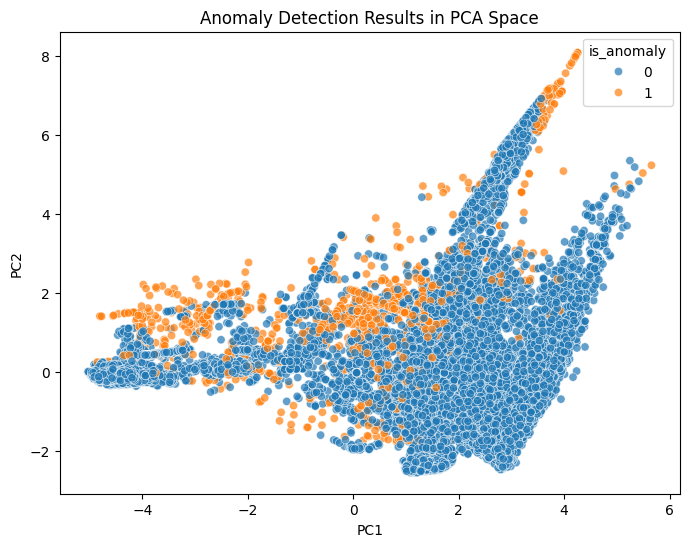

In [15]:
# ----------------------------
# Visualization of Anomalies in PCA Space
# ----------------------------
# Rebuild the PCA plotting frame and overlay Isolation Forest labels.
plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
plot_df["is_anomaly"] = df["is_anomaly"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="is_anomaly",
    alpha=0.7
)
plt.title("Anomaly Detection Results in PCA Space")
plt.show()


In [16]:
# ----------------------------
# Feature Importance Approximation
# ----------------------------
# Isolation Forest does not expose classic feature importance values.
# Using variance and class-wise mean differences as lightweight proxies.
feature_variance = X_scaled.var().sort_values(ascending=False)
print("\nTop Features by Variance:")
print(feature_variance.head(10))

# Comparing average feature values for predicted normal vs anomaly groups.
group_means = df.groupby("is_anomaly").mean(numeric_only=True).T
group_means.columns = ["Normal_Mean", "Anomaly_Mean"]
group_means["Difference"] = group_means["Anomaly_Mean"] - group_means["Normal_Mean"]
group_means = group_means.sort_values(by="Difference", key=abs, ascending=False)

print("\nTop Features Differentiating Anomalies vs Normal:")
print(group_means.head(10))



Top Features by Variance:
class                          1.00004
protocol_type                  1.00004
dst_host_same_srv_rate         1.00004
dst_host_serror_rate           1.00004
dst_host_srv_diff_host_rate    1.00004
serror_rate                    1.00004
src_bytes                      1.00004
diff_srv_rate                  1.00004
dst_host_diff_srv_rate         1.00004
dst_host_srv_serror_rate       1.00004
dtype: float64

Top Features Differentiating Anomalies vs Normal:
                        Normal_Mean  Anomaly_Mean  Difference
byte_ratio                26.894733    305.190512  278.295779
dst_bytes                361.421361    152.204663 -209.216698
src_bytes                161.310776    368.822222  207.511446
count                     79.017926    127.204762   48.186836
dst_host_count           184.208758    150.685714  -33.523044
dst_host_srv_count       116.246615     92.582540  -23.664076
dbscan_cluster             6.664466     14.857143    8.192677
srv_count            

In [17]:
# ----------------------------
# Save Outputs
# ----------------------------
# Creating output directories and persist trained artifacts / exports.
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Keeping the 10 strongest anomaly candidates (lowest anomaly_score first).
top_anomalies = df.sort_values("anomaly_score").head(10)

joblib.dump(iso_model, "models/isolation_forest_intrusion.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(pca, "models/pca.pkl")

df.to_csv("outputs/network_intrusion_with_predictions.csv", index=False)
top_anomalies.to_csv("outputs/top_10_anomalies.csv", index=False)

print("\nSaved files:")
print("- models/isolation_forest_intrusion.pkl")
print("- models/scaler.pkl")
print("- models/pca.pkl")
print("- outputs/network_intrusion_with_predictions.csv")
print("- outputs/top_10_anomalies.csv")



Saved files:
- models/isolation_forest_intrusion.pkl
- models/scaler.pkl
- models/pca.pkl
- outputs/network_intrusion_with_predictions.csv
- outputs/top_10_anomalies.csv


In [18]:
# ----------------------------
# Simple Project Summary
# ----------------------------
# Building a compact summary table for reporting / presentation.
summary_table = pd.DataFrame({
    "Model": ["Isolation Forest", "K-Means", "DBSCAN"],
    "Approach": [
        "Isolation-Based",
        "Distance-Based",
        "Density-Based"
    ],
    "Dataset Rows": [len(df), len(df), len(df)],
    "Features Used": [X.shape[1], X.shape[1], X.shape[1]],
    "Predicted Anomalies": [
        if_anomalies,
        km_anomalies,
        db_anomalies
    ],
    "Anomaly Percentage": [
        f"{if_pct}%",
        f"{km_pct}%",
        f"{db_pct}%"
    ]
})

print("\nProject Summary Table:")
print(summary_table.to_string(index=False))



Project Summary Table:
           Model        Approach  Dataset Rows  Features Used  Predicted Anomalies Anomaly Percentage
Isolation Forest Isolation-Based         25192             46                 1260               5.0%
         K-Means  Distance-Based         25192             46                 1260               5.0%
          DBSCAN   Density-Based         25192             46                 3122             12.39%


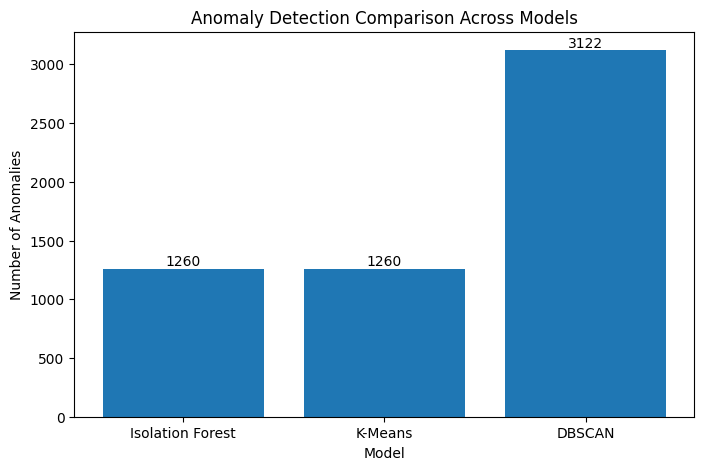

In [19]:
# ----------------------------
# Summary Visualization (Bar Chart)
# ----------------------------
# Comparing anomaly counts across models.
plt.figure(figsize=(8, 5))

plt.bar(
    summary_table["Model"],
    summary_table["Predicted Anomalies"]
)

plt.title("Anomaly Detection Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Number of Anomalies")

# Annotating each bar with its value.
for i, value in enumerate(summary_table["Predicted Anomalies"]):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()


In [20]:
# ----------------------------
# Create consensus columns for model comparison
# ----------------------------
# Consensus flags help isolate higher-confidence anomaly candidates:
# - all_three: flagged by all models
# - at_least_two: flagged by any two or more models
df["all_three"] = (
    (df["is_anomaly"] == 1) &
    (df["kmeans_anomaly"] == 1) &
    (df["dbscan_anomaly"] == 1)
).astype(int)

df["at_least_two"] = (
    df[["is_anomaly", "kmeans_anomaly", "dbscan_anomaly"]].sum(axis=1) >= 2
).astype(int)


In [21]:
# Couning consensus-based anomaly totals.
consensus = df["all_three"].sum()
at_least_two = df["at_least_two"].sum()

print("\nConsensus Anomalies (All Models):", consensus)
print("High-Confidence (At Least Two):", at_least_two)



Consensus Anomalies (All Models): 137
High-Confidence (At Least Two): 1214


In [22]:
# Final quick check: display the strongest anomaly candidates.
top_anomalies.head(10)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,byte_ratio,service_to_host_ratio,dst_host_service_ratio,is_anomaly,anomaly_score,kmeans_cluster,kmeans_distance,kmeans_anomaly,dbscan_cluster,dbscan_anomaly
11298,0.0,1,0,6,697.5,1325.625,0.0,0.0,0.0,0.0,...,0.525770,0.500000,0.666667,1,-0.117254,1,6.317343,0,-1,1
21037,0.0,1,57,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,0.777778,1.000000,1,-0.110592,0,6.015225,0,-1,1
14256,0.0,1,57,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,0.818182,1.000000,1,-0.106281,0,5.864838,0,-1,1
13005,0.0,1,57,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,0.875000,1.000000,1,-0.105839,0,5.601232,0,-1,1
24742,0.0,1,57,6,697.5,1325.625,0.0,0.0,0.0,0.0,...,0.525770,0.500000,0.218182,1,-0.103310,1,5.891388,0,-1,1
15696,0.0,1,0,8,390.0,1325.625,0.0,0.0,0.0,0.0,...,0.293979,0.333333,0.500000,1,-0.099230,1,6.441389,1,-1,1
12310,0.0,1,19,7,246.0,0.000,0.0,0.0,0.0,0.0,...,246.000000,0.500000,28.500000,1,-0.098697,1,5.841877,0,-1,1
7693,0.0,1,22,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,21.000000,63.750000,1,-0.098347,1,10.094841,1,-1,1
14345,0.0,1,22,6,241.0,1325.625,0.0,0.0,0.0,0.0,...,0.181664,0.500000,127.500000,1,-0.094035,1,9.194092,1,-1,1
13210,0.0,1,17,5,0.0,0.000,0.0,0.0,0.0,0.0,...,0.000000,1.000000,2.500000,1,-0.094015,1,6.228416,0,-1,1
